<a href="https://colab.research.google.com/github/letsemalenao/Letsema-Lenao/blob/main/Letsema_Lenao_DataScience_AI_ML_Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
#import libraries
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

#Read the CSV data
bank_data = pd.read_csv("/content/Banking_data.csv")
bank_data.tail()

,Id,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
251995,251996,8154883,43,13,single,rented,no,Surgeon,Kolkata,West_Bengal,6,11,0
251996,251997,2843572,26,10,single,rented,no,Army_officer,Rewa,Madhya_Pradesh,6,11,0
251997,251998,4522448,46,7,single,rented,no,Design_Engineer,Kalyan-Dombivli,Maharashtra,7,12,0
251998,251999,6507128,45,0,single,rented,no,Graphic_Designer,Pondicherry,Puducherry,0,10,0
251999,252000,9070230,70,17,single,rented,no,Statistician,Avadi,Tamil_Nadu,7,11,0


TASK 1: ANALYSE AND VISUALISE

In [ ]:
#check data types
print(bank_data.dtypes)

Id                    int64
Income                int64
Age                   int64
Experience            int64
Married/Single       object
House_Ownership      object
Car_Ownership        object
Profession           object
CITY                 object
STATE                object
CURRENT_JOB_YRS       int64
CURRENT_HOUSE_YRS     int64
Risk_Flag             int64
dtype: object


In [ ]:
#Check missing values
print(bank_data.isnull().sum())

Id                   0
Income               0
Age                  0
Experience           0
Married/Single       0
House_Ownership      0
Car_Ownership        0
Profession           0
CITY                 0
STATE                0
CURRENT_JOB_YRS      0
CURRENT_HOUSE_YRS    0
Risk_Flag            0
dtype: int64


In [ ]:
#Check duplicates
print (bank_data.duplicated().sum())

0


In [ ]:
#Descriptive Analysis
print("--- Dataset Summary ---")
print(bank_data.describe(include = 'all'))
#print(bank_data[['Income', 'Age', 'Experience','CURRENT_JOB_YRS', 'CURRENT_HOUSE_YRS']].describe())

--- Dataset Summary ---
                   Id        Income            Age     Experience  \
count   252000.000000  2.520000e+05  252000.000000  252000.000000   
unique            NaN           NaN            NaN            NaN   
top               NaN           NaN            NaN            NaN   
freq              NaN           NaN            NaN            NaN   
mean    126000.500000  4.997117e+06      49.954071      10.084437   
std      72746.278255  2.878311e+06      17.063855       6.002590   
min          1.000000  1.031000e+04      21.000000       0.000000   
25%      63000.750000  2.503015e+06      35.000000       5.000000   
50%     126000.500000  5.000694e+06      50.000000      10.000000   
75%     189000.250000  7.477502e+06      65.000000      15.000000   
max     252000.000000  9.999938e+06      79.000000      20.000000   

       Married/Single House_Ownership Car_Ownership Profession           CITY  \
count          252000          252000        252000     252000    

In [ ]:
numerical_cols = bank_data.select_dtypes(include=['int64']).columns
categorical_cols = bank_data.select_dtypes(include=['object']).columns
bank_data.tail()

,Id,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
251995,251996,8154883,43,13,single,rented,no,Surgeon,Kolkata,West_Bengal,6,11,0
251996,251997,2843572,26,10,single,rented,no,Army_officer,Rewa,Madhya_Pradesh,6,11,0
251997,251998,4522448,46,7,single,rented,no,Design_Engineer,Kalyan-Dombivli,Maharashtra,7,12,0
251998,251999,6507128,45,0,single,rented,no,Graphic_Designer,Pondicherry,Puducherry,0,10,0
251999,252000,9070230,70,17,single,rented,no,Statistician,Avadi,Tamil_Nadu,7,11,0


1. The Number of Loan Defaulters versus non-Defaulters

--- What is the Distribution of Loan Defaulters than non-defaulters? ---


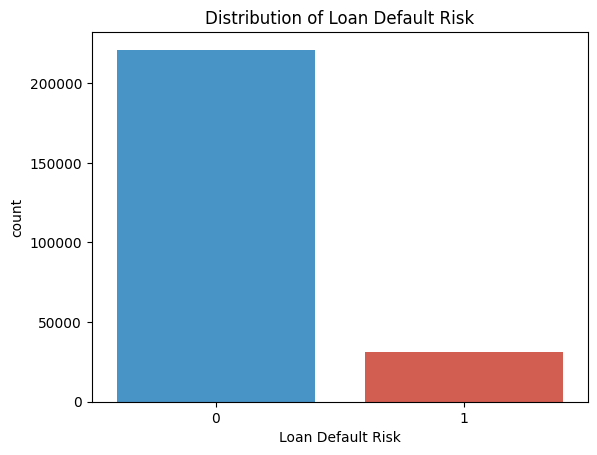


---Observation: Non-defaulters significantly outnumber defaulters, which implies an imbalaced dataset---


In [ ]:
#Distribution of Loan Default Risk
print("--- What is the Distribution of Loan Defaulters than non-defaulters? ---")
sns.countplot(
    x="Risk_Flag",
    data=bank_data,
    hue="Risk_Flag",
    palette=["#3498db", "#e74c3c"],
    legend=False,
)
plt.xlabel('Loan Default Risk')
plt.title('Distribution of Loan Default Risk')
plt.show()
print("\n---Observation: Non-defaulters significantly outnumber defaulters, which implies an imbalaced dataset---")

2. Default Rate by age

In [ ]:
# Convert Age column to numeric
bank_data['Age'] = pd.to_numeric(bank_data['Age'], errors='coerce')

# Define bins and labels
age_bins = [0, 24, 55, 100]
age_labels = ['Youth (0-24)', 'Middle_Class (25-54)', 'Senior (55+)']

# Apply binning
bank_data['Age_Group'] = pd.cut(
    bank_data['Age'],
    bins=age_bins,
    labels=age_labels,
    right=False
)

In [ ]:
# View results
bank_data[['Age', 'Age_Group']].head()

,Age,Age_Group
0,23,Youth (0-24)
1,40,Middle_Class (25-54)
2,66,Senior (55+)
3,41,Middle_Class (25-54)
4,47,Middle_Class (25-54)


In [ ]:
# Default rate by Age Category
default_by_age = bank_data.groupby('Age_Group')['Risk_Flag'].mean()

# Print default rates
print(default_by_age)

Age_Group
Youth (0-24)            0.146948
Middle_Class (25-54)    0.124916
Senior (55+)            0.117767
Name: Risk_Flag, dtype: float64


/tmp/ipykernel_3179/113491772.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_by_age = bank_data.groupby('Age_Group')['Risk_Flag'].mean()



--- Does age affect the probability of loan default?---


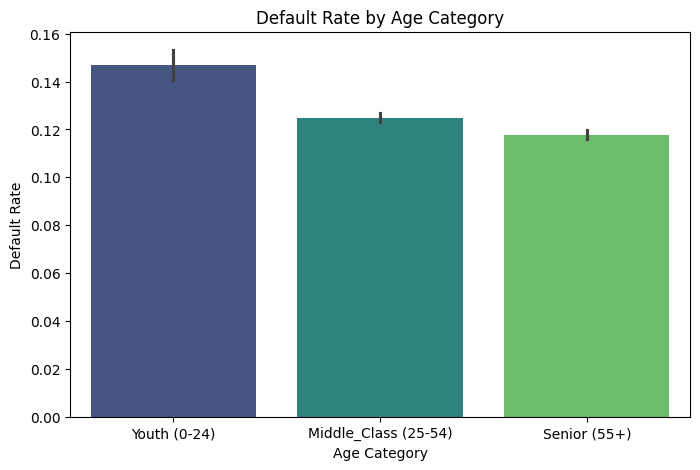


--- Observation: Younger customers tend to show slightly higher financial risk ---


In [ ]:
print("\n--- Does age affect the probability of loan default?---")
plt.figure(figsize=(8,5))
sns.barplot(
    x='Age_Group',
    y='Risk_Flag',
    hue='Age_Group',
    data=bank_data,
    palette='viridis',
    order=age_labels,
    legend=False
)

plt.title('Default Rate by Age Category')
plt.xlabel('Age Category')
plt.ylabel('Default Rate')
plt.xticks(rotation=0)

plt.show()
print("\n--- Observation: Younger customers tend to show slightly higher financial risk ---")

3. Default Rate by Experience

In [ ]:
# Create experience categories
exp_bins = [0, 5, 10, 20, 40]
exp_labels = ['0-4 yrs', '5-9 yrs', '10-19 yrs', '20+ yrs']

bank_data['Experience_Group'] = pd.cut(
    bank_data['Experience'],
    bins=exp_bins,
    labels=exp_labels,
    right=False
)

# Calculate default rate
default_by_exp = bank_data.groupby('Experience_Group')['Risk_Flag'].mean()

# Display results
print(default_by_exp)

Experience_Group
0-4 yrs      0.144301
5-9 yrs      0.119738
10-19 yrs    0.115496
20+ yrs      0.113128
Name: Risk_Flag, dtype: float64


/tmp/ipykernel_3179/3184722133.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_by_exp = bank_data.groupby('Experience_Group')['Risk_Flag'].mean()



--- Does job experience affect the probability of loan default?---


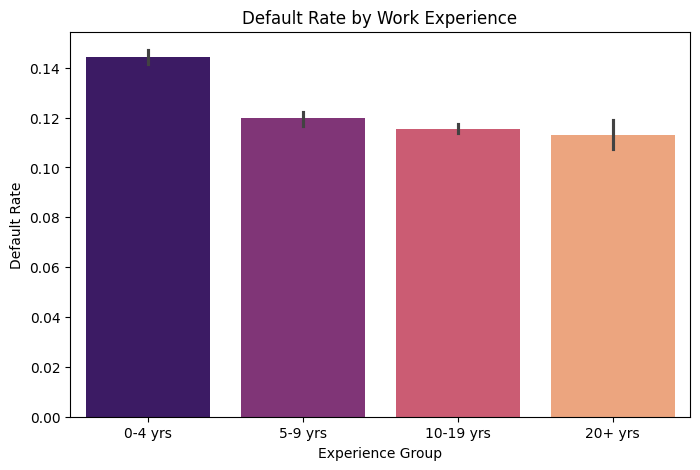

Observation:Customers with longer job experience demonstrate better repayment behaviour


In [ ]:
print("\n--- Does job experience affect the probability of loan default?---")
plt.figure(figsize=(8,5))
#default_by_exp.plot(kind='bar')
sns.barplot(
    x='Experience_Group',
    y='Risk_Flag',
    hue='Experience_Group',
    data=bank_data,
    palette='magma',
    order=exp_labels,
    legend=False
)

plt.title('Default Rate by Work Experience')
plt.xlabel('Experience Group')
plt.ylabel('Default Rate')
plt.xticks(rotation=0)

plt.show()
print("Observation:Customers with longer job experience demonstrate better repayment behaviour")

4. Default Rate by Profession

Which profession is associated with a higher default risk?


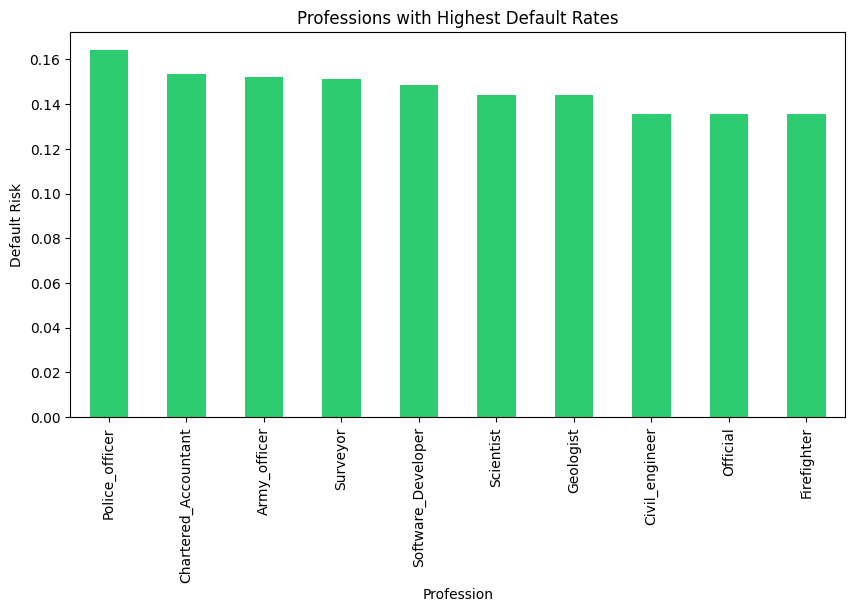

Observation: Police officers exhibit the highest loan default rate


In [ ]:
print("Which profession is associated with a higher default risk?")
profession_risk = bank_data.groupby('Profession')['Risk_Flag'].mean().sort_values(ascending=False).head(10)

profession_risk.plot(kind='bar', figsize=(10,5), color='#2ecc71')
plt.xlabel('Profession')
plt.title('Professions with Highest Default Rates')
plt.ylabel('Default Risk')
plt.show()
print("Observation: Police officers exhibit the highest loan default rate")

5. Defaulters by Marital Status

In [ ]:
# Filter only defaulters
defaulters = bank_data[bank_data['Risk_Flag'] == 1]
# Count marital status
marital_counts = defaulters['Married/Single'].value_counts()

Is there a relationship between marital status and loan default?


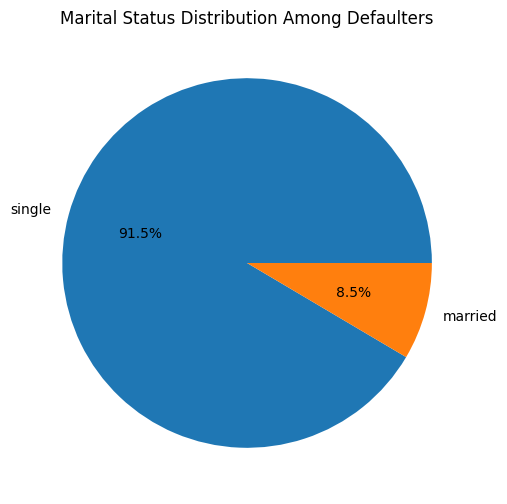

Observation: Married customers are less likely to default


In [ ]:
print("Is there a relationship between marital status and loan default?")
# Plot pie chart
plt.figure(figsize=(6,6))

plt.pie(
    marital_counts,
    labels=marital_counts.index,
    autopct='%1.1f%%'
)

plt.title('Marital Status Distribution Among Defaulters')

plt.show()
print("Observation: Married customers are less likely to default")

6. Defaulters by house ownership

Does house ownership influence repayment behavior?


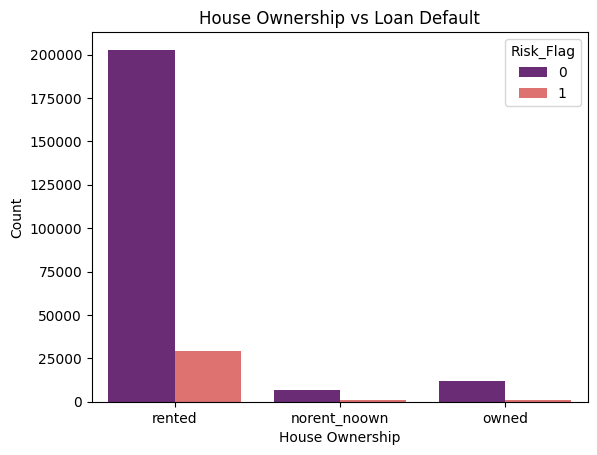

Observation: Customers with a house are less likely to default


In [ ]:
print("Does house ownership influence repayment behavior?")
# Plot countplot
sns.countplot(x='House_Ownership', hue='Risk_Flag', data=bank_data, palette='magma')
plt.xlabel('House Ownership')
plt.ylabel('Count')
plt.title('House Ownership vs Loan Default')
plt.show()
print("Observation: Customers with a house are less likely to default")

7. Defaulters by Car ownership

Does car ownership influence repayment behavior?


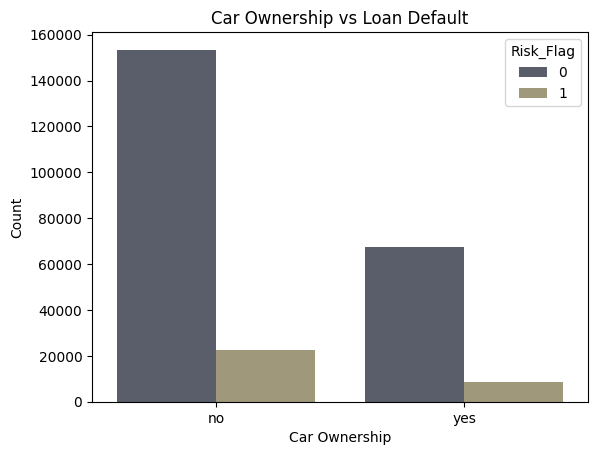

Observation: Customers with a car are less likely to default


In [ ]:
print("Does car ownership influence repayment behavior?")
# Plot countplot
sns.countplot(x='Car_Ownership', hue='Risk_Flag', data=bank_data, palette='cividis')
plt.xlabel('Car Ownership')
plt.ylabel('Count')
plt.title('Car Ownership vs Loan Default')
plt.show()
print("Observation: Customers with a car are less likely to default")

8. Age-to-experience

In [ ]:
# Create Experience to Age Ratio Feature

bank_data['Experience_Age_Ratio'] = bank_data['Experience'] / bank_data['Age']

In [ ]:
#View Results
print(bank_data[['Age', 'Experience', 'Experience_Age_Ratio']].head())

   Age  Experience  Experience_Age_Ratio
0   23           3              0.130435
1   40          10              0.250000
2   66           4              0.060606
3   41           2              0.048780
4   47          11              0.234043


In [ ]:
#Handle possible division errors
bank_data['Experience_Age_Ratio'] = bank_data['Experience'] / (bank_data['Age'] + 1)

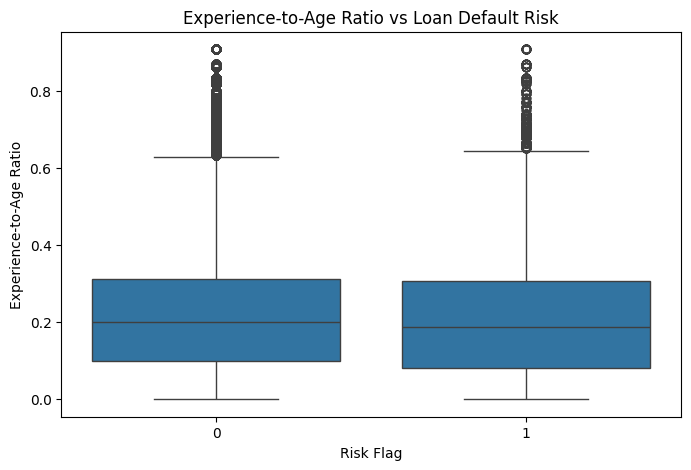

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Risk_Flag',
    y='Experience_Age_Ratio',
    data=bank_data
)

plt.title('Experience-to-Age Ratio vs Loan Default Risk')
plt.xlabel('Risk Flag')
plt.ylabel('Experience-to-Age Ratio')

plt.show()

In [ ]:
ratio_analysis = bank_data.groupby('Risk_Flag')['Experience_Age_Ratio'].mean()

print(ratio_analysis)

Risk_Flag
0    0.226646
1    0.220074
Name: Experience_Age_Ratio, dtype: float64



--- Does borrower's age to their year's of exprience affect the probability of loan default?---


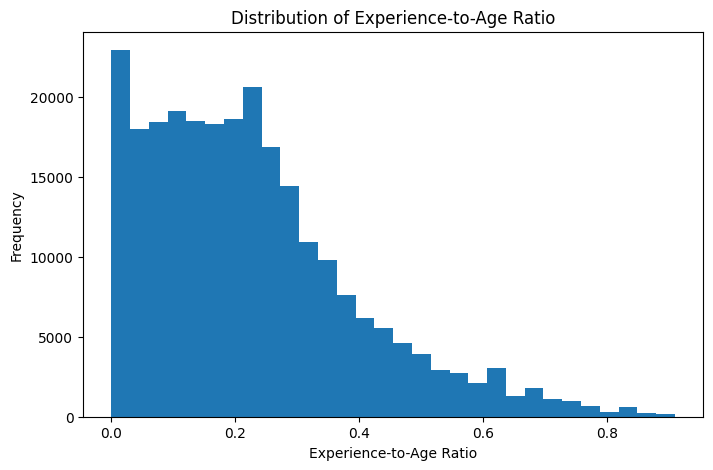

Younger borrowers with disproportionately short experience demonstrate less financial stability, potentially correlating to higher default risk


In [ ]:
print("\n---Does a borrower’s age relative to their years of experience affect the probability of loan default?---")
plt.figure(figsize=(8,5))

plt.hist(bank_data['Experience_Age_Ratio'], bins=30)

plt.title('Distribution of Experience-to-Age Ratio')
plt.xlabel('Experience-to-Age Ratio')
plt.ylabel('Frequency')

plt.show()
print("Younger borrowers with disproportionately short experience demonstrate less financial stability, potentially correlating to higher default risk")

9. Distributio of Age

10. Distribution of Income

Does income affect the probability of default?


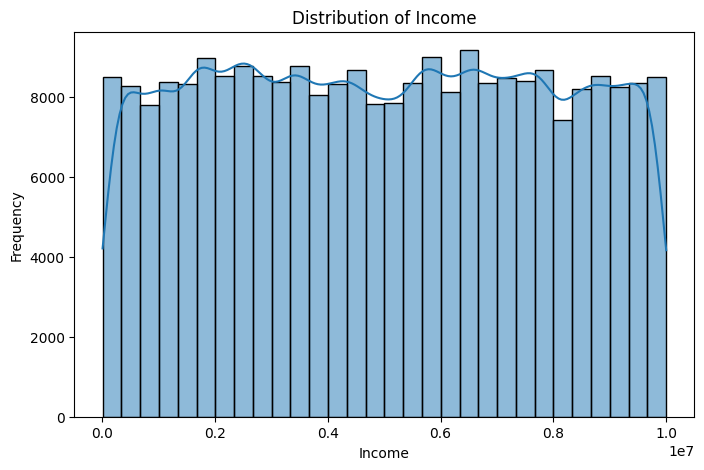

Observation: Customers with unstable income patterns appear more likely to default


In [ ]:
print("Does income affect the probability of default?")
plt.figure(figsize=(8,5))

sns.histplot(bank_data['Income'], bins=30, kde=True)

plt.title('Distribution of Income')
plt.xlabel('Income')
plt.ylabel('Frequency')

plt.show()
print("Observation: Customers with unstable income patterns appear more likely to default")

In [ ]:
#Default percentage
risk_rate = bank_data['Risk_Flag'].mean() * 100

print(f"\nOverall Default Rate: {risk_rate:.2f}%")


Overall Default Rate: 12.30%


TASK 2: DATA CLEANING

1. Checking Missing Values

In [ ]:
print(bank_data.isnull().sum())

Income                  0
Age                     0
Experience              0
Married/Single          0
House_Ownership         0
Car_Ownership           0
Profession              0
CITY                    0
STATE                   0
CURRENT_JOB_YRS         0
CURRENT_HOUSE_YRS       0
Risk_Flag               0
Age_Group               0
Experience_Group        0
Experience_Age_Ratio    0
dtype: int64


2. Removing Duplicates

In [ ]:
bank_data = bank_data.drop_duplicates()

3. Dropping Irrelevant Columns

In [ ]:
bank_data = bank_data.drop("Id", axis=1, errors="ignore")
bank_data.head()

,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag,Age_Group,Experience_Group,Experience_Age_Ratio
0,1303834,23,3,1,2,0,33,251,13,3,13,0,2,0-4 yrs,0.125000
1,7574516,40,10,1,2,0,43,227,14,9,13,0,0,10-19 yrs,0.243902
2,3991815,66,4,0,2,0,47,8,12,4,10,0,1,0-4 yrs,0.059701
3,6256451,41,2,1,2,1,43,54,17,2,12,1,0,0-4 yrs,0.047619
4,5768871,47,11,1,2,0,11,296,22,3,14,1,0,10-19 yrs,0.229167


4. Encoding Categorical Variables

In [ ]:
#Machine learning models require numerical data
X = pd.get_dummies(X, drop_first=True)

5. Feature and Target Separation

In [ ]:
X = bank_data.drop('Risk_Flag', axis=1)
y = bank_data['Risk_Flag']

6. Train-Test Split

In [ ]:
#Separating training and testing data helps evaluate model performance fairly
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

7. Feature Scaling: Scaling improves logistic regression because variables are standardised

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# Select only columns that are integers or floats
X_train_numeric = X_train.select_dtypes(include=["int64", "float64"])
X_test_numeric = X_test.select_dtypes(include=["int64", "float64"])

X_train_scaled = scaler.fit_transform(X_train_numeric)
X_test_scaled = scaler.transform(X_test_numeric)

TASK 3: MACHINE LEARNING MODEL DEVELOPMENT - LOGISTIC REGRESSION

In [ ]:
#Logic regression implementation
from sklearn.linear_model import LogisticRegression

#Filter X_train and X_test to ONLY keep numerical columns
X_train_numeric = X_train.select_dtypes(include=["number"])
X_test_numeric = X_test.select_dtypes(include=["number"])

#Initialize the model
model = LogisticRegression(max_iter=1000, class_weight="balanced")

#Fit the model using ONLY the numeric data
model.fit(X_train_numeric, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
#Making Predictions using numeric data
y_pred = model.predict(X_test_numeric)

In [ ]:
print("Success! Predictions generated safely.")
print("First 5 predictions:", y_pred[:10])

Success! Predictions generated safely.
First 5 predictions: [1 0 0 1 1 0 0 1 1 0]


TASK 4: MODEL EVALUATION

1. Accuracy Score

In [ ]:
from sklearn.metrics import accuracy_score
print("=== Accuracy Score ===")
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy)

=== Accuracy Score ===
Accuracy: 0.5152813151192406


2. Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
print("=== Confusion Matrix ===")
cm = confusion_matrix(y_test, y_pred)
print(cm)

=== Confusion Matrix ===
[[3726 3256]
 [ 931  725]]


3. Classification Report

In [ ]:
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))


=== Classification Report ===
              precision    recall  f1-score   support

           0       0.80      0.53      0.64      6982
           1       0.18      0.44      0.26      1656

    accuracy                           0.52      8638
   macro avg       0.49      0.49      0.45      8638
weighted avg       0.68      0.52      0.57      8638

